In [ ]:
from pathlib import Path

data_path = Path("iot_data.csv")
if not data_path.exists():
    raise FileNotFoundError("iot_data.csv was not found in the current folder.")

print(f"Using local file: {data_path.resolve()}")

Using local file: D:\intern IIT\IoT-Based-patient-Monitoring-System-using-sensor-Arduino-and-Machine-learning--main\iot_data.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json

In [ ]:
df = pd.read_csv(data_path)

In [ ]:
print(df.head())

       r_id       reg_no                                       field_value3  \
0  107342.0  25PSITCS011  {"884":"0.00","885":"0.00","886":"27.94","887"...   
1  107341.0  25PSITCS011  {"884":"0.00","885":"0.00","886":"28.06","887"...   
2  107340.0  25PSITCS011  {"884":"0.00","885":"0.00","886":"27.75","887"...   
3  107339.0  25PSITCS011  {"884":"17.23","885":"93.00","886":"27.81","88...   
4  107298.0  25PSITCS011  {"884":"0.00","885":"0.00","886":"29.88","887"...   

   p_id             iot_date  
0   NaN  2026-05-05 16:48:37  
1   NaN  2026-05-05 16:42:25  
2   NaN  2026-05-05 16:38:46  
3   NaN  2026-05-05 16:37:16  
4   NaN  2026-05-04 19:27:40  


In [ ]:
df["parsed"] = df["field_value3"].apply(lambda x: json.loads(x))

df["BPM"] = df["parsed"].apply(lambda x: float(x.get("884", 0)))
df["SPO2"] = df["parsed"].apply(lambda x: float(x.get("885", 0)))
df["Body_Temp"] = df["parsed"].apply(lambda x: float(x.get("886", 0)))
df["Ambient_Temp"] = df["parsed"].apply(lambda x: float(x.get("887", 0)))
df["Humidity"] = df["parsed"].apply(lambda x: float(x.get("888", 0)))

df_clean = df[["BPM", "SPO2", "Body_Temp", "Ambient_Temp", "Humidity"]]

df_clean.insert(0, "SNo", range(1, len(df_clean)+1))

In [ ]:
print(df_clean.head())

   SNo    BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0    1   0.00   0.0      27.94          29.3      63.0
1    2   0.00   0.0      28.06          28.9      63.0
2    3   0.00   0.0      27.75          28.5      64.0
3    4  17.23  93.0      27.81          28.0      65.0
4    5   0.00   0.0      29.88          30.8      56.0


In [ ]:
df_clean

,SNo,BPM,SPO2,Body_Temp,Ambient_Temp,Humidity
0,1,0.00,0.0,27.94,29.3,63.0
1,2,0.00,0.0,28.06,28.9,63.0
2,3,0.00,0.0,27.75,28.5,64.0
3,4,17.23,93.0,27.81,28.0,65.0
4,5,0.00,0.0,29.88,30.8,56.0
...,...,...,...,...,...,...
113,114,75.67,97.0,24.44,0.0,0.0
114,115,70.92,97.0,24.44,0.0,0.0
115,116,0.00,0.0,24.31,0.0,0.0
116,117,16.01,0.0,24.44,0.0,0.0


In [ ]:
print(df_clean.describe())

              SNo         BPM        SPO2   Body_Temp  Ambient_Temp  \
count  118.000000  118.000000  118.000000  118.000000    117.000000   
mean    59.500000   31.924576   44.262712   24.964576     20.152991   
std     34.207699   33.889333   48.403296    5.319996     12.469138   
min      1.000000    0.000000    0.000000   19.310000      0.000000   
25%     30.250000    0.000000    0.000000   19.440000      0.000000   
50%     59.500000   16.975000    0.000000   24.595000     22.200000   
75%     88.750000   70.000000   97.000000   30.000000     30.800000   
max    118.000000   83.350000   99.000000   36.500000     31.800000   

         Humidity  
count  117.000000  
mean    42.299145  
std     25.048665  
min      0.000000  
25%      0.000000  
50%     55.000000  
75%     58.000000  
max     65.000000  


In [ ]:
# Count invalid values (zeros)
print("Invalid values count:")
print("BPM zeros:", (df_clean["BPM"] == 0).sum())
print("SPO2 zeros:", (df_clean["SPO2"] == 0).sum())

Invalid values count:
BPM zeros: 56
SPO2 zeros: 64


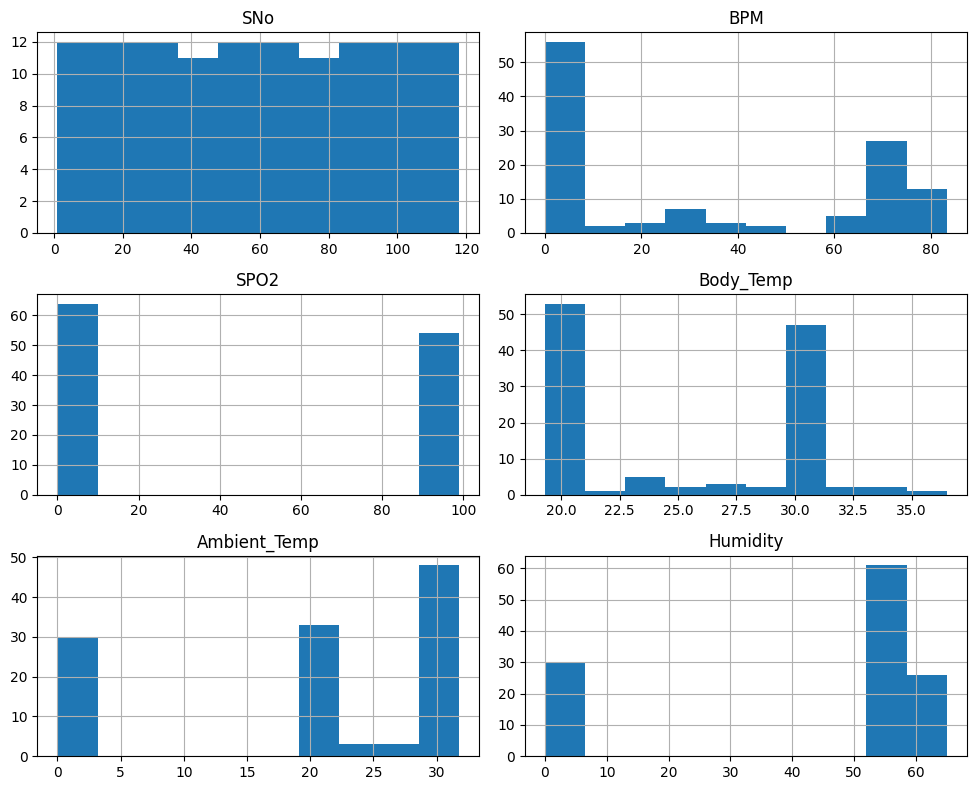

In [ ]:
df_clean.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

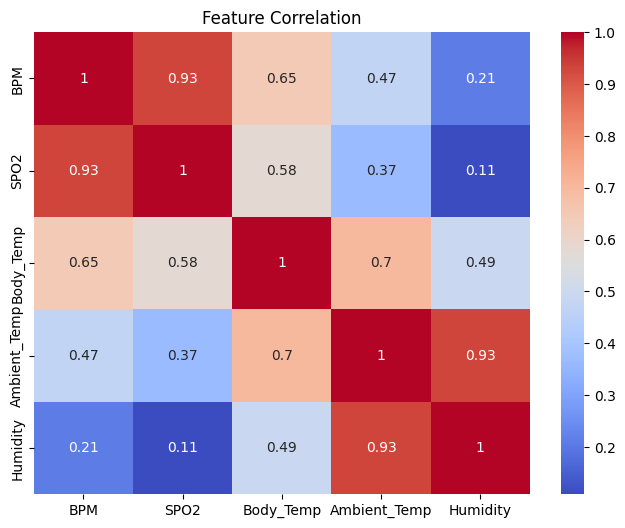

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_clean.drop("SNo", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [ ]:
df_model = df_clean.copy()

# Replace invalid zero readings with NaN
sensor_cols = ["BPM", "SPO2", "Body_Temp", "Ambient_Temp", "Humidity"]
df_model[sensor_cols] = df_model[sensor_cols].replace(0, np.nan)

# Check missing values after replacement
print("Missing values after replacing zeros:")
print(df_model.isnull().sum())

# Fill missing values with median
for col in sensor_cols:
    df_model[col] = df_model[col].fillna(df_model[col].median())

# Remove duplicates if any
df_model = df_model.drop_duplicates()

# Final cleaned preview
print(df_model.head())

# Verify zeros are gone
print("\nZero count after cleaning:")
print((df_model[sensor_cols] == 0).sum())

Missing values after replacing zeros:
SNo              0
BPM             56
SPO2            64
Body_Temp        0
Ambient_Temp    31
Humidity        31
dtype: int64
   SNo    BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0    1  70.00  97.0      27.94          29.3      63.0
1    2  70.00  97.0      28.06          28.9      63.0
2    3  70.00  97.0      27.75          28.5      64.0
3    4  17.23  93.0      27.81          28.0      65.0
4    5  70.00  97.0      29.88          30.8      56.0

Zero count after cleaning:
BPM             0
SPO2            0
Body_Temp       0
Ambient_Temp    0
Humidity        0
dtype: int64


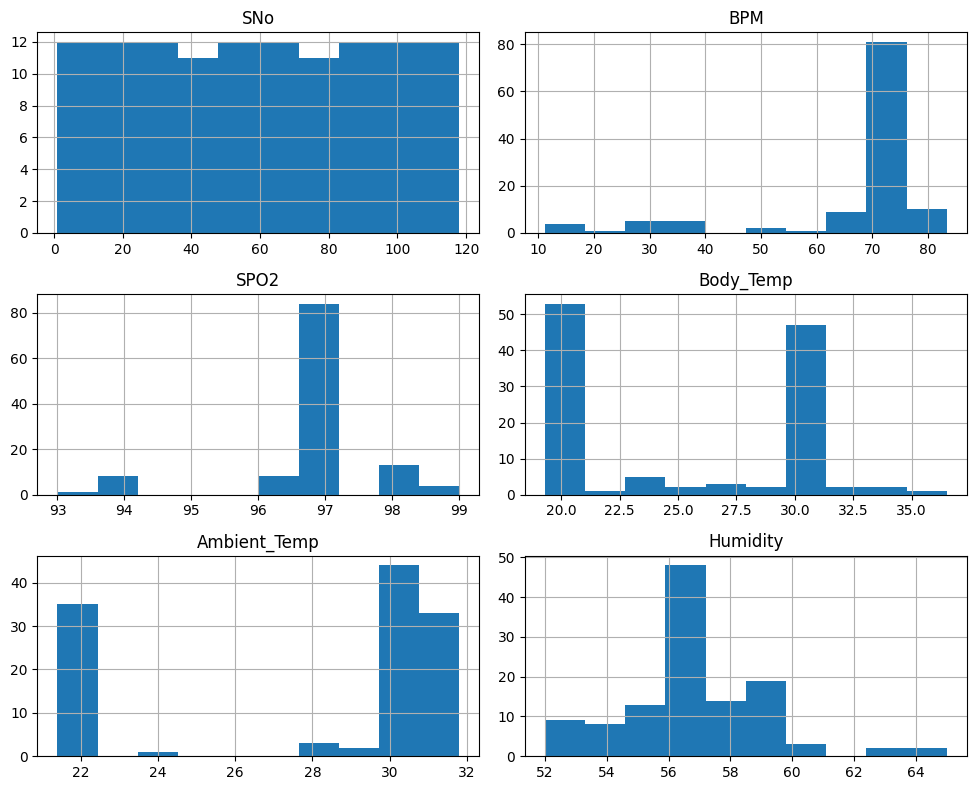

In [ ]:
df_model.hist(figsize=(10,8))
plt.tight_layout()
plt.show()

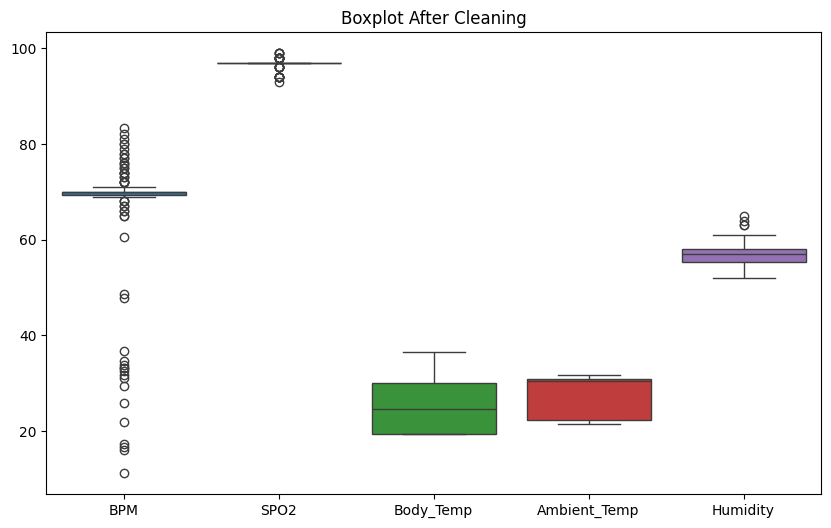

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df_model.drop("SNo", axis=1))
plt.title("Boxplot After Cleaning")
plt.show()

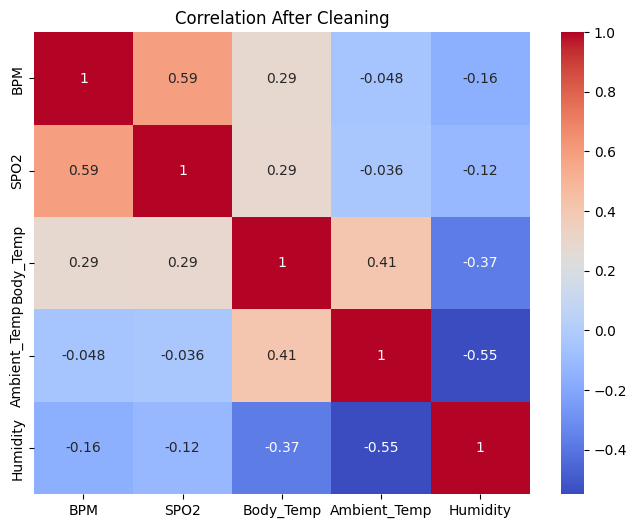

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df_model.drop("SNo", axis=1).corr(), annot=True, cmap="coolwarm")
plt.title("Correlation After Cleaning")
plt.show()

In [ ]:
# IQR method for BPM
Q1 = df_model["BPM"].quantile(0.25)
Q3 = df_model["BPM"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Clip values
df_model["BPM"] = df_model["BPM"].clip(lower_bound, upper_bound)

# Check again
print("New BPM range:", df_model["BPM"].min(), df_model["BPM"].max())

New BPM range: 68.125 71.125


In [ ]:
# Features only (drop SNo)
X = df_model.drop("SNo", axis=1)

# Check data
print(X.head())
print("Shape:", X.shape)

      BPM  SPO2  Body_Temp  Ambient_Temp  Humidity
0  70.000  97.0      27.94          29.3      63.0
1  70.000  97.0      28.06          28.9      63.0
2  70.000  97.0      27.75          28.5      64.0
3  68.125  93.0      27.81          28.0      65.0
4  70.000  97.0      29.88          30.8      56.0
Shape: (118, 5)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (94, 5)
Test shape: (24, 5)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data
X_test_scaled = scaler.transform(X_test)

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(contamination=0.1, random_state=42)

model.fit(X_train_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.1
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [ ]:
y_test_pred = model.predict(X_test_scaled)

# Convert labels
y_test_pred = ["Normal" if x == 1 else "Abnormal" for x in y_test_pred]

import pandas as pd
print(pd.Series(y_test_pred).value_counts())

Normal      19
Abnormal     5
Name: count, dtype: int64


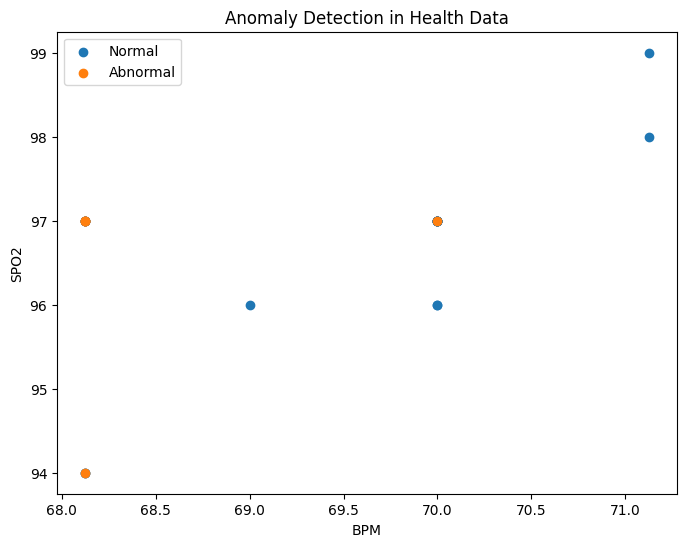

In [ ]:
import matplotlib.pyplot as plt

# Convert test data back to DataFrame
df_test = X_test.copy()
df_test["Anomaly"] = y_test_pred

# Plot
plt.figure(figsize=(8,6))

normal = df_test[df_test["Anomaly"] == "Normal"]
abnormal = df_test[df_test["Anomaly"] == "Abnormal"]

plt.scatter(normal["BPM"], normal["SPO2"], label="Normal")
plt.scatter(abnormal["BPM"], abnormal["SPO2"], label="Abnormal")

plt.xlabel("BPM")
plt.ylabel("SPO2")
plt.title("Anomaly Detection in Health Data")
plt.legend()
plt.show()

In [ ]:
import joblib

joblib.dump(model, "anomaly_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']